# Streaming Consumer and Prediction Monitoring

This notebook represents the reporting layer of the building energy prediction pipeline. The upstream Spark Structured Streaming job reads live weather messages, applies the saved machine learning model, and publishes corrected prediction outputs to Kafka. This notebook consumes those prediction topics, checks the message quality, rebuilds reporting-level tables, and creates visual outputs for project documentation.

The focus is on monitoring predicted energy consumption at the correct business grain: building-level predictions over 6-hour windows and site-level summaries derived from those building-window predictions.


## 1. Runtime setup

The consumer runs as a downstream analytics notebook. It connects to Kafka, reads the prediction topics produced by the streaming model, and uses pandas and matplotlib for lightweight analysis and reporting.


In [3]:
# ==========================================
# 1. Import Libraries
# ==========================================

import json
import socket
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from kafka import KafkaConsumer
from kafka.admin import KafkaAdminClient

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Project and Kafka configuration

The prediction notebook writes to versioned Kafka topics so that new model outputs do not mix with earlier experimental messages. The consumer reads from the `v2` topics created after the log-target model update.


In [6]:
# ==========================================
# 2. Configure Project Paths and Kafka Topics
# ==========================================

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "screenshots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use False when running from Mac/Anaconda/VS Code.
# Use True only if this notebook itself runs inside the Docker network.
RUNNING_INSIDE_DOCKER = False
KAFKA_BROKER = "kafka:9092" if RUNNING_INSIDE_DOCKER else "localhost:9092"

# Kafka output topics written by spark_streaming_prediction.ipynb
PREDICTIONS_RAW_TOPIC = "predictions_raw_v2"
PREDICTIONS_6H_TOPIC = "predictions_6h_v2"
PREDICTIONS_DAILY_TOPIC = "predictions_daily_v2"

# Consumer limits
MAX_RAW_MESSAGES = 1000
MAX_6H_MESSAGES = 5000
MAX_DAILY_MESSAGES = 2000
CONSUMER_TIMEOUT_MS = 45000

TIMEZONE = "Australia/Melbourne"

print("Configuration loaded.")
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Kafka broker:", KAFKA_BROKER)
print("Raw prediction topic:", PREDICTIONS_RAW_TOPIC)
print("6-hour prediction topic:", PREDICTIONS_6H_TOPIC)
print("Daily prediction topic:", PREDICTIONS_DAILY_TOPIC)
print("Output directory:", OUTPUT_DIR)


Configuration loaded.
Project root: /Users/harshithreddy/building-energy-prediction-streaming
Data directory: /Users/harshithreddy/building-energy-prediction-streaming/data
Kafka broker: localhost:9092
Raw prediction topic: predictions_raw_v2
6-hour prediction topic: predictions_6h_v2
Daily prediction topic: predictions_daily_v2
Output directory: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots


## 3. Kafka connection check

Before consuming prediction records, the notebook checks that the local Kafka broker is reachable. This prevents silent failures later in the reporting workflow.


In [9]:
# ==========================================
# 3. Validate Kafka Connection and Topics
# ==========================================

def check_kafka_connection(broker=KAFKA_BROKER, timeout=5):
    host, port = broker.split(":")
    port = int(port)

    try:
        with socket.create_connection((host, port), timeout=timeout):
            print(f"Kafka broker is reachable: {broker}")
            return True
    except Exception as exc:
        raise ConnectionError(
            f"Kafka broker is not reachable at {broker}. "
            "Start Docker, Zookeeper and Kafka before running this notebook."
        ) from exc


def list_kafka_topics(broker=KAFKA_BROKER):
    admin_client = None

    try:
        admin_client = KafkaAdminClient(
            bootstrap_servers=[broker],
            client_id="consumer_visualisation_admin",
            request_timeout_ms=10000
        )
        topics = sorted(admin_client.list_topics())
        return topics
    finally:
        if admin_client is not None:
            admin_client.close()


check_kafka_connection()

topics = list_kafka_topics()
print("\nAvailable Kafka topics:")
for topic in topics:
    print("-", topic)

expected_topics = [
    PREDICTIONS_RAW_TOPIC,
    PREDICTIONS_6H_TOPIC,
    PREDICTIONS_DAILY_TOPIC
]

missing_topics = [topic for topic in expected_topics if topic not in topics]

if missing_topics:
    print("\nWarning: these expected prediction topics were not found:", missing_topics)
    print("Run the Spark streaming prediction notebook before running the consumer visualisation.")
else:
    print("\nAll expected prediction topics are available.")


Kafka broker is reachable: localhost:9092

Available Kafka topics:
- __consumer_offsets
- predictions_6h
- predictions_6h_v2
- predictions_daily
- predictions_daily_v2
- predictions_raw
- predictions_raw_v2
- weather_stream

All expected prediction topics are available.


## 4. Kafka consumer helper

A bounded Kafka consumer is used for notebook execution. Each run uses a unique consumer group and starts from the earliest available offset, which makes the notebook suitable for repeated testing during development.


In [12]:
# ==========================================
# 4. Define Kafka Consumer Helper
# ==========================================

def decode_kafka_value(raw_value):
    try:
        return json.loads(raw_value.decode("utf-8"))
    except Exception:
        return {"raw_value": raw_value.decode("utf-8", errors="replace")}


def consume_kafka_messages(topic, num_messages=100, timeout_ms=CONSUMER_TIMEOUT_MS):
    """
    Consume JSON messages from a Kafka topic into a pandas DataFrame.
    """

    consumer = KafkaConsumer(
        topic,
        bootstrap_servers=[KAFKA_BROKER],
        auto_offset_reset="earliest",
        enable_auto_commit=False,
        consumer_timeout_ms=timeout_ms,
        group_id=f"energy_consumer_{topic}_{int(time.time())}"
    )

    messages = []

    try:
        for message in consumer:
            payload = decode_kafka_value(message.value)

            if isinstance(payload, dict):
                payload["_topic"] = message.topic
                payload["_partition"] = message.partition
                payload["_offset"] = message.offset
                messages.append(payload)

            if len(messages) >= num_messages:
                break
    finally:
        consumer.close()

    if not messages:
        print(f"No messages consumed from topic: {topic}")
        return pd.DataFrame()

    df = pd.DataFrame(messages)
    print(f"Consumed {len(df)} messages from topic: {topic}")
    return df


print("Kafka consumer helper defined.")


Kafka consumer helper defined.


## 5. Consume prediction topics

The consumer reads raw prediction records, 6-hour building-level predictions, and daily prediction messages. The downstream visualisations are rebuilt primarily from the 6-hour topic because that is the model’s direct prediction grain.


In [15]:
# ==========================================
# 5. Consume Prediction Messages from Kafka
# ==========================================

df_raw = consume_kafka_messages(
    topic=PREDICTIONS_RAW_TOPIC,
    num_messages=MAX_RAW_MESSAGES,
    timeout_ms=CONSUMER_TIMEOUT_MS
)

df_6h = consume_kafka_messages(
    topic=PREDICTIONS_6H_TOPIC,
    num_messages=MAX_6H_MESSAGES,
    timeout_ms=CONSUMER_TIMEOUT_MS
)

df_daily_stream = consume_kafka_messages(
    topic=PREDICTIONS_DAILY_TOPIC,
    num_messages=MAX_DAILY_MESSAGES,
    timeout_ms=CONSUMER_TIMEOUT_MS
)

print("Raw prediction shape:", df_raw.shape)
print("6-hour prediction shape:", df_6h.shape)
print("Daily stream prediction shape:", df_daily_stream.shape)


Consumed 1000 messages from topic: predictions_raw_v2
Consumed 5000 messages from topic: predictions_6h_v2
Consumed 299 messages from topic: predictions_daily_v2
Raw prediction shape: (1000, 11)
6-hour prediction shape: (5000, 8)
Daily stream prediction shape: (299, 8)


## 6. Standardise consumed prediction data

Kafka messages are converted into typed pandas DataFrames. The 6-hour prediction table is deduplicated by `site_id`, `building_id`, and `window_start` so repeated micro-batch messages do not inflate daily totals.


In [18]:
# ==========================================
# 6. Standardise and Deduplicate Prediction Data
# ==========================================

def parse_project_datetime(series, timezone=TIMEZONE):
    """
    Parse Kafka timestamp fields while preserving local project time.
    """

    if series.empty:
        return pd.to_datetime(series)

    sample = series.dropna().astype(str)

    if sample.empty:
        return pd.to_datetime(series, errors="coerce")

    has_timezone_marker = sample.str.contains(
        r"(Z$|[+-]\d{2}:\d{2}$)",
        regex=True
    ).any()

    if has_timezone_marker:
        return (
            pd.to_datetime(series, errors="coerce", utc=True)
            .dt.tz_convert(timezone)
            .dt.tz_localize(None)
        )

    return pd.to_datetime(series, errors="coerce")


def standardise_6h_predictions(df):
    if df.empty:
        return df

    df = df.copy()

    if "total_energy_6h" in df.columns and "predicted_energy_6h" not in df.columns:
        df = df.rename(columns={"total_energy_6h": "predicted_energy_6h"})

    required_columns = {
        "building_id",
        "site_id",
        "window_start",
        "predicted_energy_6h"
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(f"6-hour prediction data is missing columns: {sorted(missing_columns)}")

    df["building_id"] = pd.to_numeric(df["building_id"], errors="coerce")
    df["site_id"] = pd.to_numeric(df["site_id"], errors="coerce")
    df["window_start"] = parse_project_datetime(df["window_start"])
    df["predicted_energy_6h"] = pd.to_numeric(df["predicted_energy_6h"], errors="coerce")

    if "event_time" in df.columns:
        df["event_time"] = parse_project_datetime(df["event_time"])

    if "_offset" not in df.columns:
        df["_offset"] = np.arange(len(df))

    df = (
        df
        .dropna(subset=["building_id", "site_id", "window_start", "predicted_energy_6h"])
        .copy()
    )

    df["building_id"] = df["building_id"].astype(int)
    df["site_id"] = df["site_id"].astype(int)
    df["predicted_energy_6h"] = df["predicted_energy_6h"].clip(lower=0)

    df = (
        df
        .sort_values(["site_id", "building_id", "window_start", "_offset"])
        .drop_duplicates(
            subset=["site_id", "building_id", "window_start"],
            keep="last"
        )
        .reset_index(drop=True)
    )

    return df


def standardise_daily_predictions(df):
    if df.empty:
        return df

    df = df.copy()

    if "total_energy_daily" in df.columns and "predicted_energy_daily" not in df.columns:
        df = df.rename(columns={"total_energy_daily": "predicted_energy_daily"})

    required_columns = {
        "site_id",
        "day",
        "predicted_energy_daily"
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(f"Daily prediction data is missing columns: {sorted(missing_columns)}")

    df["site_id"] = pd.to_numeric(df["site_id"], errors="coerce")
    df["day"] = parse_project_datetime(df["day"]).dt.floor("D")
    df["predicted_energy_daily"] = pd.to_numeric(df["predicted_energy_daily"], errors="coerce")

    if "building_count" in df.columns:
        df["building_count"] = pd.to_numeric(df["building_count"], errors="coerce")

    return df.dropna(subset=["site_id", "day", "predicted_energy_daily"]).copy()


df_6h = standardise_6h_predictions(df_6h)
df_daily_stream = standardise_daily_predictions(df_daily_stream)

if not df_6h.empty:
    print("6-hour predictions after deduplication:", len(df_6h))
    display(df_6h.head())

if not df_daily_stream.empty:
    print("Daily stream messages consumed:", len(df_daily_stream))
    display(df_daily_stream.head())


6-hour predictions after deduplication: 5000


/var/folders/b1/k55jnhtj1sng1ghwn0plswsw0000gn/T/ipykernel_6787/3675694469.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_timezone_marker = sample.str.contains(
/var/folders/b1/k55jnhtj1sng1ghwn0plswsw0000gn/T/ipykernel_6787/3675694469.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_timezone_marker = sample.str.contains(
/var/folders/b1/k55jnhtj1sng1ghwn0plswsw0000gn/T/ipykernel_6787/3675694469.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_timezone_marker = sample.str.contains(


,site_id,building_id,window_start,event_time,predicted_energy_6h,_topic,_partition,_offset
0,0,0,2021-12-31 23:00:00,2022-01-01 04:00:00,180.148769,predictions_6h_v2,0,1
1,0,0,2022-01-01 11:00:00,2022-01-01 16:00:00,67.028823,predictions_6h_v2,0,2
2,0,0,2022-01-01 23:00:00,2022-01-02 04:00:00,34.659733,predictions_6h_v2,0,3
3,0,0,2022-01-02 17:00:00,2022-01-02 22:00:00,11.551364,predictions_6h_v2,0,0
4,0,0,2022-01-02 23:00:00,2022-01-03 04:00:00,10.190203,predictions_6h_v2,0,4


Daily stream messages consumed: 299


,site_id,day,building_count,predicted_energy_daily,event_time,_topic,_partition,_offset
0,0,2022-01-01,78,42503.715678,2026-09-08T21:52:11.010+10:00,predictions_daily_v2,0,0
1,2,2022-01-03,99,19307.155019,2026-09-08T21:52:11.010+10:00,predictions_daily_v2,0,1
2,0,2022-01-05,78,15813.181420,2026-09-08T21:52:11.010+10:00,predictions_daily_v2,0,2
3,0,2022-01-04,78,10829.048924,2026-09-08T21:52:11.010+10:00,predictions_daily_v2,0,3
4,3,2022-01-06,185,30400.133796,2026-09-08T21:52:11.010+10:00,predictions_daily_v2,0,4


## 7. Build reporting tables

Daily site totals are rebuilt from the deduplicated 6-hour building predictions. This keeps the reporting layer consistent with the model output and avoids double-counting messages when the same window appears in more than one micro-batch.


In [21]:
# ==========================================
# 7. Build Reporting Tables from 6-Hour Predictions
# ==========================================

daily_from_6h = pd.DataFrame()
building_summary = pd.DataFrame()
site_summary = pd.DataFrame()

if df_6h.empty:
    print("No 6-hour prediction messages are available. Run the streaming prediction notebook first.")
else:
    df_6h["day"] = df_6h["window_start"].dt.floor("D")

    daily_from_6h = (
        df_6h
        .groupby(["site_id", "day"], as_index=False)
        .agg(
            predicted_energy_daily=("predicted_energy_6h", "sum"),
            building_count=("building_id", "nunique"),
            prediction_windows=("window_start", "nunique")
        )
        .sort_values(["day", "site_id"])
        .reset_index(drop=True)
    )

    building_summary = (
        df_6h
        .groupby(["site_id", "building_id"], as_index=False)
        .agg(
            predicted_energy_total=("predicted_energy_6h", "sum"),
            average_6h_prediction=("predicted_energy_6h", "mean"),
            prediction_windows=("window_start", "nunique")
        )
        .sort_values("predicted_energy_total", ascending=False)
        .reset_index(drop=True)
    )

    site_summary = (
        daily_from_6h
        .groupby("site_id", as_index=False)
        .agg(
            predicted_energy_total=("predicted_energy_daily", "sum"),
            average_daily_prediction=("predicted_energy_daily", "mean"),
            observed_days=("day", "nunique"),
            average_building_count=("building_count", "mean")
        )
        .sort_values("predicted_energy_total", ascending=False)
        .reset_index(drop=True)
    )

    print("Reporting tables created.")
    print("Daily rows:", len(daily_from_6h))
    print("Building summary rows:", len(building_summary))
    print("Site summary rows:", len(site_summary))

    print("\nDaily prediction sample:")
    display(daily_from_6h.head())

    print("\nTop predicted buildings:")
    display(building_summary.head(10))

    print("\nSite summary:")
    display(site_summary.head(10))


Reporting tables created.
Daily rows: 42
Building summary rows: 467
Site summary rows: 6

Daily prediction sample:


,site_id,day,predicted_energy_daily,building_count,prediction_windows
0,0,2021-12-31,12816.204907,38,1
1,1,2021-12-31,3968.249875,17,1
2,2,2021-12-31,2481.469017,57,1
3,3,2021-12-31,2934.452265,82,1
4,4,2021-12-31,4066.924807,20,1



Top predicted buildings:


,site_id,building_id,predicted_energy_total,average_6h_prediction,prediction_windows
0,1,119,10178.553567,782.965659,13
1,1,121,9889.798520,760.753732,13
2,1,113,7649.174699,588.398054,13
3,1,107,6420.662841,535.055237,12
4,4,583,5941.043504,660.115945,9
5,4,572,5471.473767,607.941530,9
6,4,569,5233.382227,523.338223,10
7,4,594,4633.074311,421.188574,11
8,4,589,4174.604382,596.372055,7
9,1,129,3990.346303,306.949716,13



Site summary:


,site_id,predicted_energy_total,average_daily_prediction,observed_days,average_building_count
0,3,130462.247163,18637.463880,7,157.714286
1,1,92416.658274,13202.379753,7,29.571429
2,4,82960.426418,11851.489488,7,36.142857
3,0,63796.611715,9113.801674,7,65.285714
4,2,56167.520897,8023.931557,7,85.142857
5,5,1730.981250,247.283036,7,3.714286


## 8. Prediction distribution check

Before plotting trends, the notebook checks the distribution of building-level 6-hour predictions. This is useful after changing the model from raw target prediction to log-target prediction because it confirms that prediction values are on the corrected energy scale.


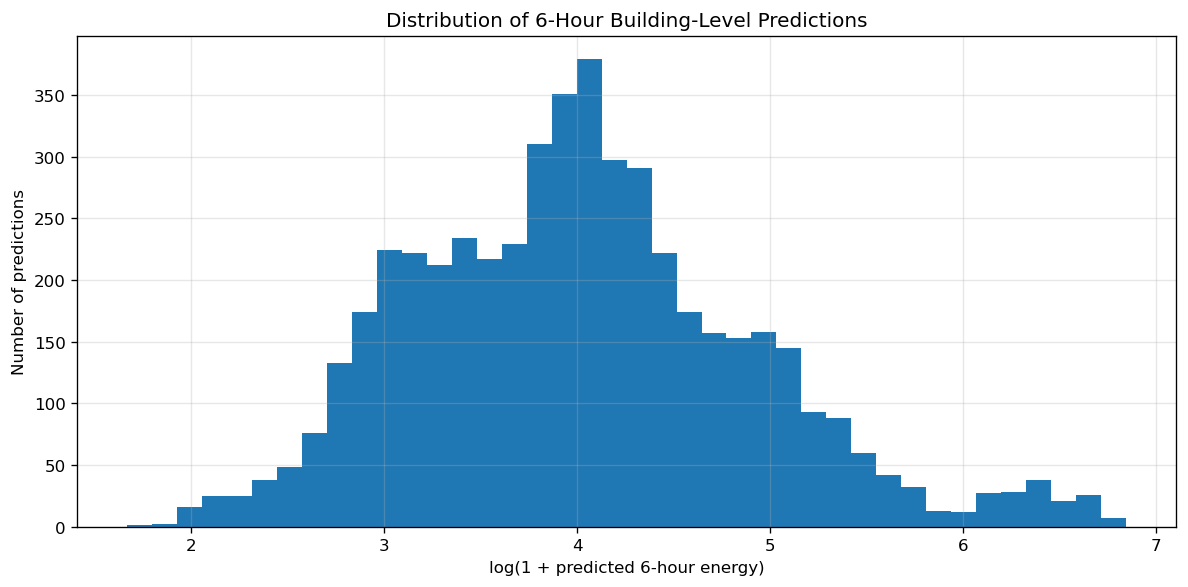

Prediction distribution plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_prediction_distribution.png


In [24]:
# ==========================================
# 8. Visualise Prediction Distribution
# ==========================================

plot_path_distribution = OUTPUT_DIR / "streaming_prediction_distribution.png"

if df_6h.empty:
    print("Skipping distribution plot because no 6-hour predictions were consumed.")
else:
    plt.figure(figsize=(10, 5))
    plt.hist(
        np.log1p(df_6h["predicted_energy_6h"]),
        bins=40
    )
    plt.xlabel("log(1 + predicted 6-hour energy)")
    plt.ylabel("Number of predictions")
    plt.title("Distribution of 6-Hour Building-Level Predictions")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_path_distribution, dpi=150, bbox_inches="tight")
    plt.show()

    print("Prediction distribution plot saved to:", plot_path_distribution)


## 9. Building-level prediction trend

The 6-hour trend chart shows how predicted consumption changes across time for the highest predicted buildings. This view is useful for operational monitoring because large buildings or unusual building patterns can be identified quickly.


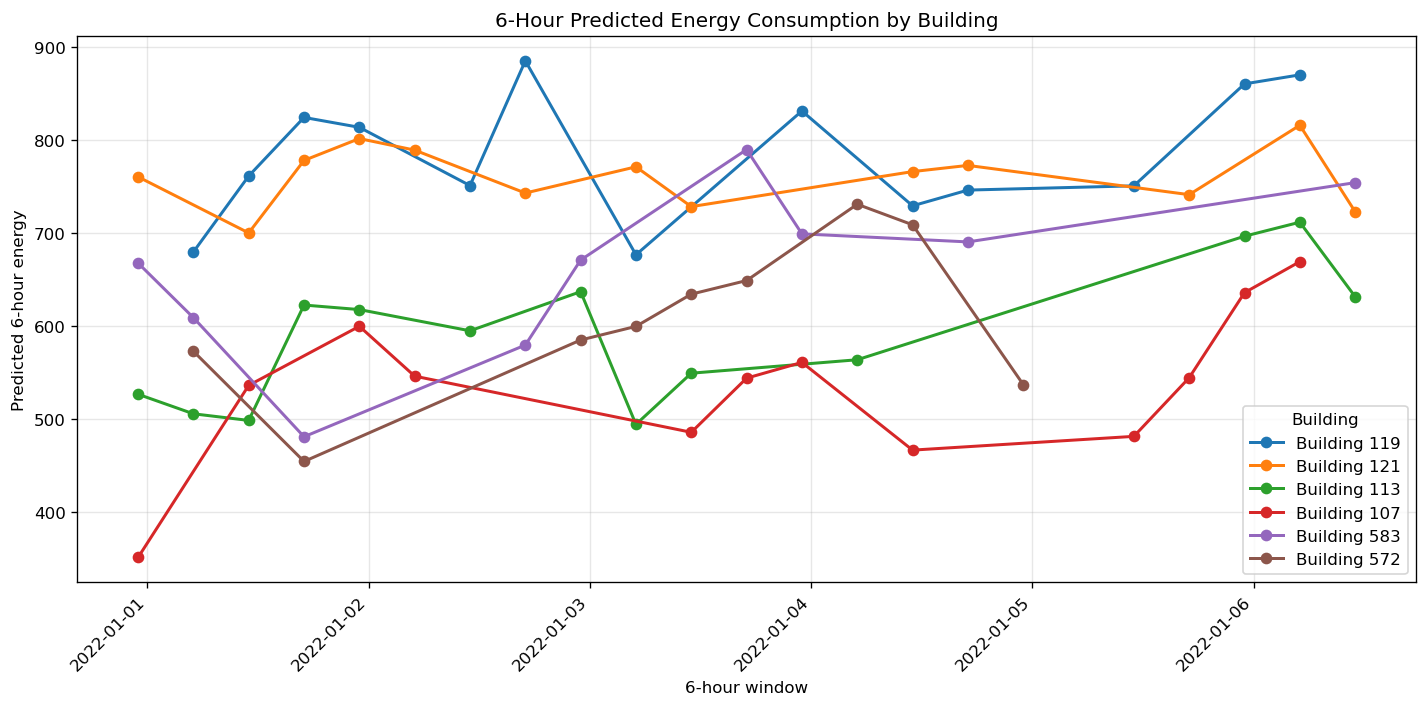

6-hour prediction plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_predictions_6h.png


In [27]:
# ==========================================
# 9. Visualise 6-Hour Building-Level Predictions
# ==========================================

plot_path_6h = OUTPUT_DIR / "streaming_predictions_6h.png"

if df_6h.empty:
    print("Skipping 6-hour plot because no prediction messages were consumed.")
else:
    top_buildings = (
        building_summary
        .head(6)["building_id"]
        .tolist()
    )

    plt.figure(figsize=(12, 6))

    for building_id in top_buildings:
        building_data = (
            df_6h[df_6h["building_id"] == building_id]
            .sort_values("window_start")
        )

        plt.plot(
            building_data["window_start"],
            building_data["predicted_energy_6h"],
            marker="o",
            linewidth=1.8,
            label=f"Building {int(building_id)}"
        )

    plt.xlabel("6-hour window")
    plt.ylabel("Predicted 6-hour energy")
    plt.title("6-Hour Predicted Energy Consumption by Building")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Building")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(plot_path_6h, dpi=150, bbox_inches="tight")
    plt.show()

    print("6-hour prediction plot saved to:", plot_path_6h)


## 10. Daily site-level demand summary

Site-level daily totals are rebuilt from deduplicated 6-hour predictions. This produces a cleaner reporting view than directly summing all consumed daily topic messages, because it controls the reporting grain inside the consumer notebook.


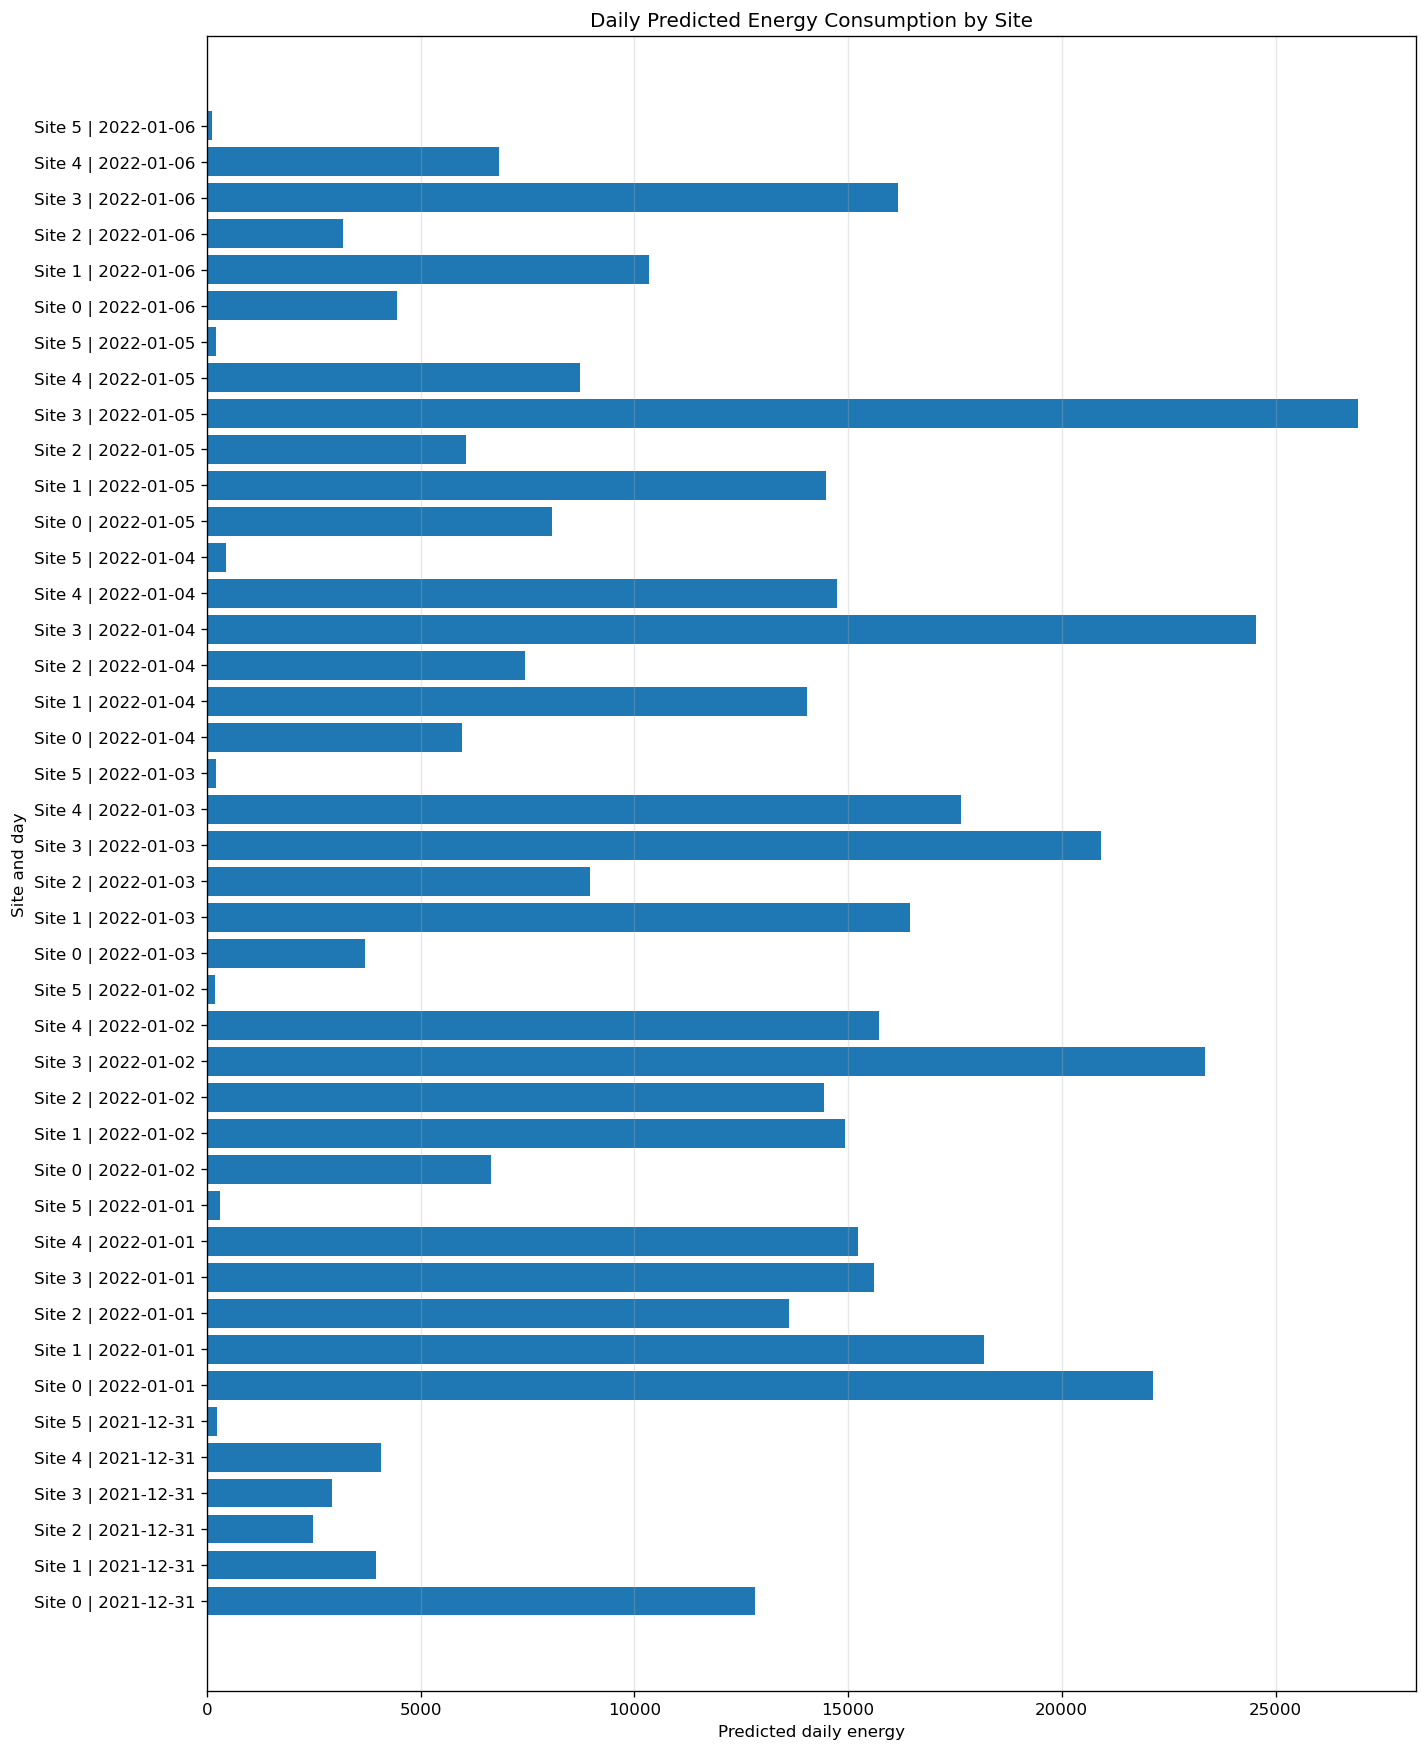

Daily prediction plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_predictions_daily.png


In [30]:
# ==========================================
# 10. Visualise Daily Site-Level Predictions
# ==========================================

plot_path_daily = OUTPUT_DIR / "streaming_predictions_daily.png"

if daily_from_6h.empty:
    print("Skipping daily plot because no daily reporting table was created.")
else:
    daily_plot_df = daily_from_6h.copy()
    daily_plot_df["site_day"] = (
        "Site " + daily_plot_df["site_id"].astype(int).astype(str)
        + " | " + daily_plot_df["day"].dt.strftime("%Y-%m-%d")
    )

    plt.figure(figsize=(12, max(5, len(daily_plot_df) * 0.35)))
    plt.barh(daily_plot_df["site_day"], daily_plot_df["predicted_energy_daily"])
    plt.xlabel("Predicted daily energy")
    plt.ylabel("Site and day")
    plt.title("Daily Predicted Energy Consumption by Site")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()

    plt.savefig(plot_path_daily, dpi=150, bbox_inches="tight")
    plt.show()

    print("Daily prediction plot saved to:", plot_path_daily)


## 11. Site ranking

The site ranking summarises which locations have the highest predicted energy demand in the consumed stream. In a production environment, this type of view can support prioritisation for energy monitoring, demand response, or building operations review.


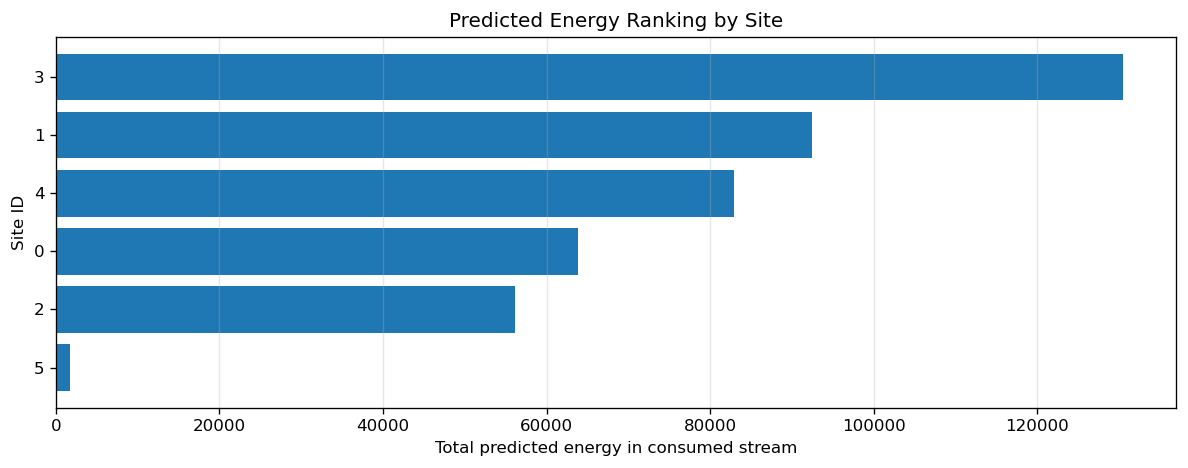

Site ranking plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_site_ranking.png


In [33]:
# ==========================================
# 11. Visualise Site Ranking
# ==========================================

plot_path_site_ranking = OUTPUT_DIR / "streaming_site_ranking.png"

if site_summary.empty:
    print("Skipping site ranking because site summary is unavailable.")
else:
    plt.figure(figsize=(10, max(4, len(site_summary) * 0.35)))
    plt.barh(
        site_summary["site_id"].astype(int).astype(str),
        site_summary["predicted_energy_total"]
    )
    plt.xlabel("Total predicted energy in consumed stream")
    plt.ylabel("Site ID")
    plt.title("Predicted Energy Ranking by Site")
    plt.gca().invert_yaxis()
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()

    plt.savefig(plot_path_site_ranking, dpi=150, bbox_inches="tight")
    plt.show()

    print("Site ranking plot saved to:", plot_path_site_ranking)


## 12. Final project figure

The final figure combines the key prediction-monitoring outputs from the consumer notebook into one image for the GitHub README or project report. It focuses only on consumed Kafka predictions, rebuilt reporting tables, and site-level demand summaries.


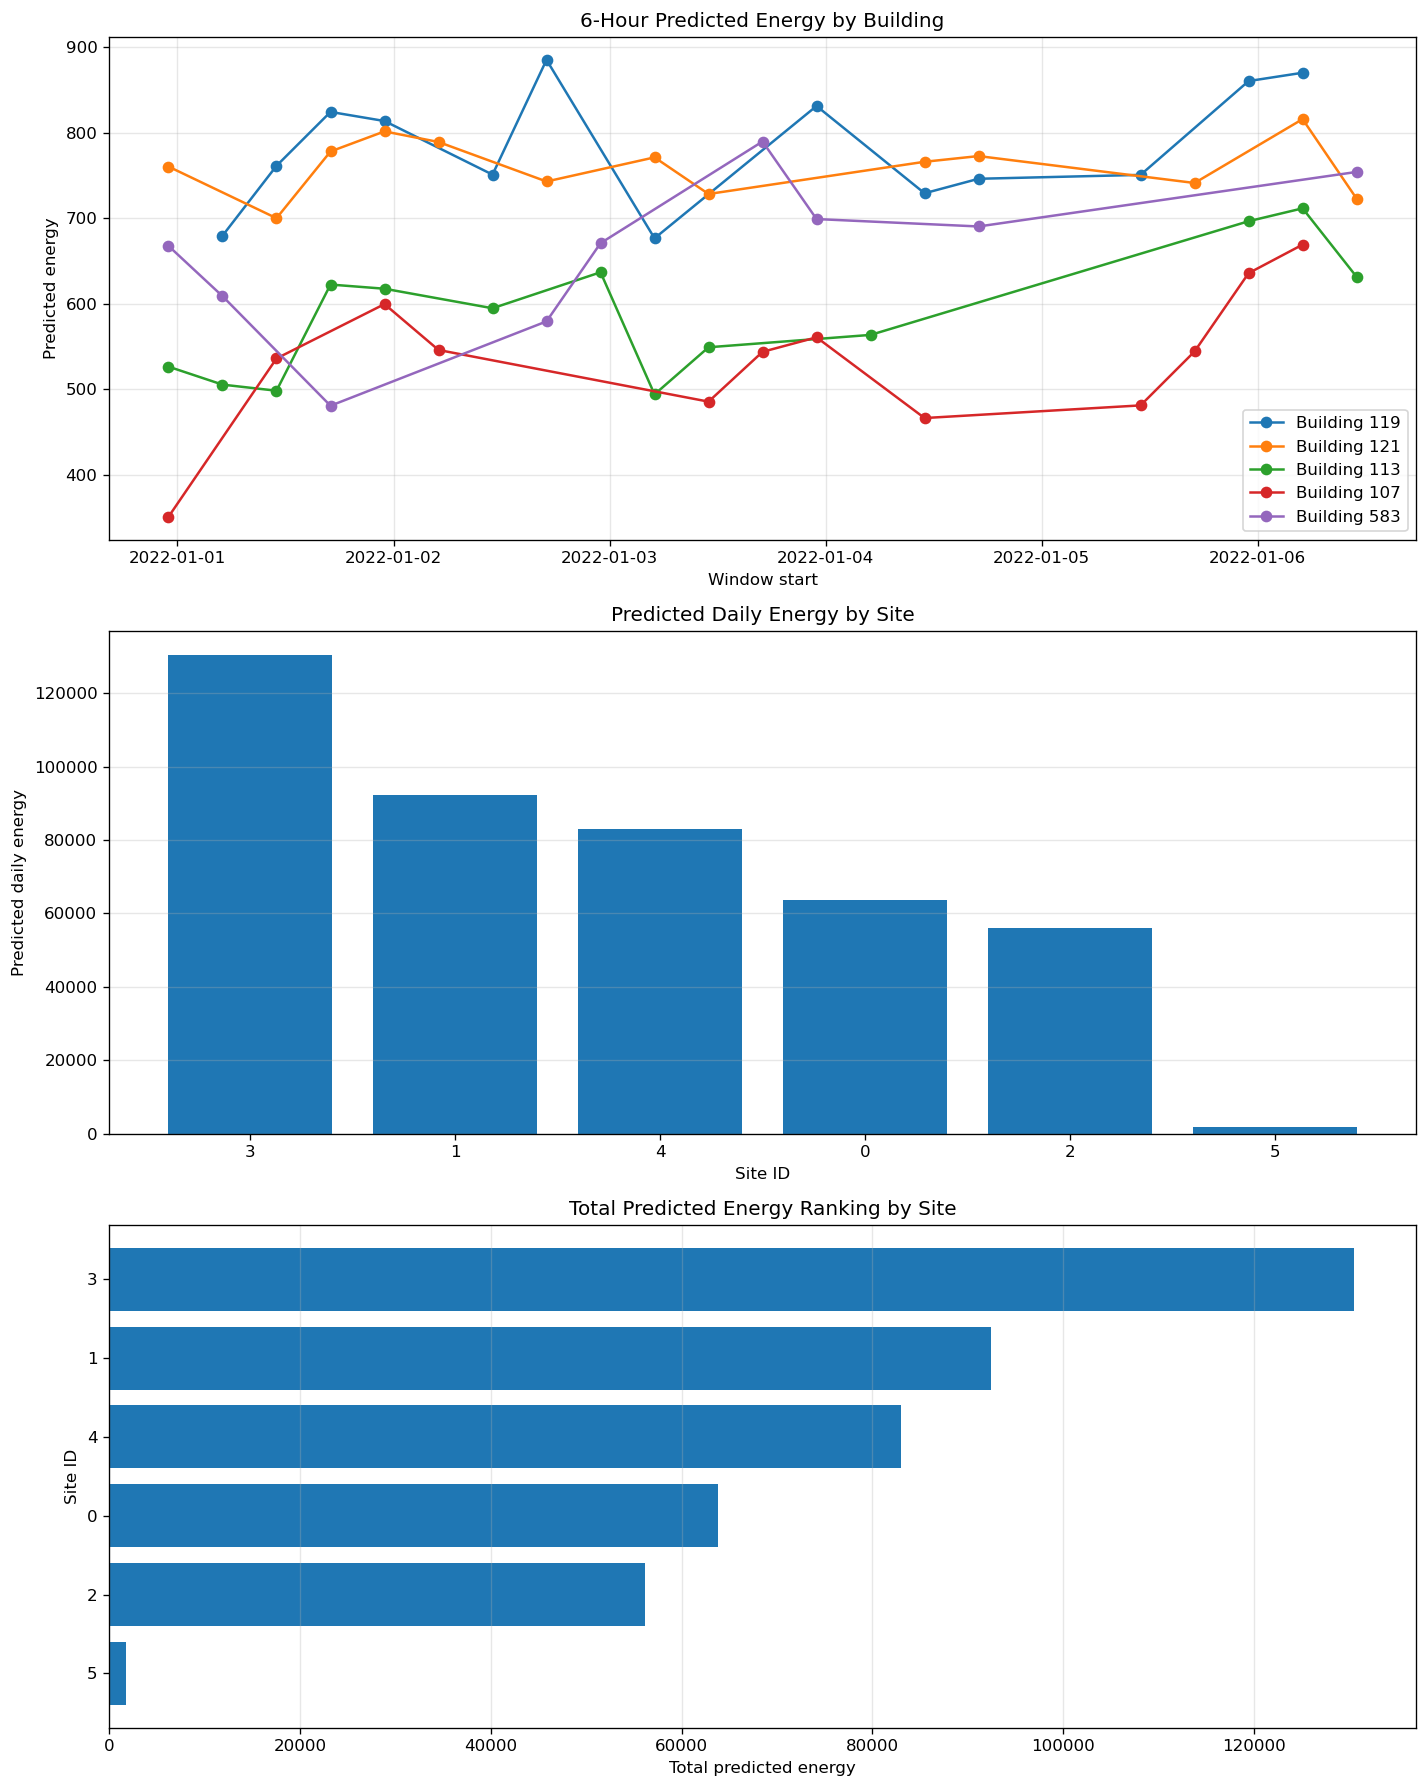

Combined streaming visualisation saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_predictions.png


In [36]:
# ==========================================
# 12. Save Combined Streaming Visualisation
# ==========================================

combined_plot_path = OUTPUT_DIR / "streaming_predictions.png"

has_6h = not df_6h.empty
has_daily = not daily_from_6h.empty
has_site_summary = not site_summary.empty

if not any([has_6h, has_daily, has_site_summary]):
    print("No combined visual output created because no prediction data was available.")
else:
    panels = []

    if has_6h:
        panels.append("6h")
    if has_daily:
        panels.append("daily")
    if has_site_summary:
        panels.append("site")

    rows = len(panels)
    fig, axes = plt.subplots(rows, 1, figsize=(12, 5 * rows))

    if rows == 1:
        axes = [axes]

    axis_index = 0

    if has_6h:
        ax = axes[axis_index]
        top_buildings = building_summary.head(5)["building_id"].tolist()

        for building_id in top_buildings:
            building_data = (
                df_6h[df_6h["building_id"] == building_id]
                .sort_values("window_start")
            )

            ax.plot(
                building_data["window_start"],
                building_data["predicted_energy_6h"],
                marker="o",
                linewidth=1.5,
                label=f"Building {int(building_id)}"
            )

        ax.set_title("6-Hour Predicted Energy by Building")
        ax.set_xlabel("Window start")
        ax.set_ylabel("Predicted energy")
        ax.legend()
        ax.grid(True, alpha=0.3)
        axis_index += 1

    if has_daily:
        ax = axes[axis_index]
        daily_summary = (
            daily_from_6h
            .groupby("site_id", as_index=False)["predicted_energy_daily"]
            .sum()
            .sort_values("predicted_energy_daily", ascending=False)
        )

        ax.bar(
            daily_summary["site_id"].astype(int).astype(str),
            daily_summary["predicted_energy_daily"]
        )
        ax.set_title("Predicted Daily Energy by Site")
        ax.set_xlabel("Site ID")
        ax.set_ylabel("Predicted daily energy")
        ax.grid(True, axis="y", alpha=0.3)
        axis_index += 1

    if has_site_summary:
        ax = axes[axis_index]
        top_site_summary = site_summary.head(10)

        ax.barh(
            top_site_summary["site_id"].astype(int).astype(str),
            top_site_summary["predicted_energy_total"]
        )
        ax.set_title("Total Predicted Energy Ranking by Site")
        ax.set_xlabel("Total predicted energy")
        ax.set_ylabel("Site ID")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(combined_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Combined streaming visualisation saved to:", combined_plot_path)


## 13. Notebook summary

The consumer stage converts Kafka prediction messages into reporting outputs. The key deliverable is a set of streaming prediction charts saved under `outputs/screenshots`. This version focuses only on monitoring the streaming prediction outputs.


In [41]:
# ==========================================
# 13. Notebook Summary
# ==========================================

print("Streaming consumer visualisation completed.")
print("Raw prediction records:", len(df_raw))
print("6-hour prediction records after deduplication:", len(df_6h))
print("Daily stream records consumed:", len(df_daily_stream))
print("Daily rows rebuilt from 6-hour predictions:", len(daily_from_6h))
print("Output folder:", OUTPUT_DIR)

created_files = [
    OUTPUT_DIR / "streaming_prediction_distribution.png",
    OUTPUT_DIR / "streaming_predictions_6h.png",
    OUTPUT_DIR / "streaming_predictions_daily.png",
    OUTPUT_DIR / "streaming_site_ranking.png",
    OUTPUT_DIR / "streaming_predictions.png"
]

print("Created output files:")
for file_path in created_files:
    if file_path.exists():
        print("-", file_path)


Streaming consumer visualisation completed.
Raw prediction records: 1000
6-hour prediction records after deduplication: 5000
Daily stream records consumed: 299
Daily rows rebuilt from 6-hour predictions: 42
Output folder: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots
Created output files:
- /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_prediction_distribution.png
- /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_predictions_6h.png
- /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_predictions_daily.png
- /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_site_ranking.png
- /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/streaming_predictions.png
